In [1]:
import geopandas as gpd
import pandas as pd
import os, json, xmltodict, math
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib
import load_data as ld
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline

In [30]:
shapefile_path = os.path.join(os.getcwd(), "shapefile")

#cwbxml
with open(os.getcwd()+"\\xml\\cwb.xml", encoding="utf-8") as xml_file:
    data_dict = xmltodict.parse(xml_file.read())
    cwb_data = json.loads(json.dumps(data_dict, ensure_ascii=False).encode("utf-8").decode())
    Identifier = cwb_data["earthquake"]["identifier"]
    Schemaver = cwb_data["earthquake"]["schemaVer"]
    Language = cwb_data["earthquake"]["language"]
    Sendername = cwb_data["earthquake"]["senderName"]
    Senttime = cwb_data["earthquake"]["sent"]
    Status = cwb_data["earthquake"]["status"]
    Msgtype = cwb_data["earthquake"]["msgType"]
    MsgNo = cwb_data["earthquake"]["msgNo"]
    Description = cwb_data["earthquake"]["description"]
    Origintime = cwb_data["earthquake"]["originTime"]
    Lat = float(cwb_data["earthquake"]["epicenter"]["epicenterLat"]["#text"])
    Lon = float(cwb_data["earthquake"]["epicenter"]["epicenterLon"]["#text"])
    Depth = cwb_data["earthquake"]["depth"]["#text"]
    Magnitude = cwb_data["earthquake"]["magnitude"]["magnitudeValue"]
    pgaAdj = cwb_data["earthquake"]["pgaAdj"]

    cwb_origin_time = datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00").timestamp()

In [31]:
town = gpd.read_file(shapefile_path+"\TOWN_MOI_1091016.shp", encoding="utf-8")
county = gpd.read_file(shapefile_path+"\COUNTY_MOI_1090820.shp", encoding="utf-8")
crs = county.crs

2021-03-04 22:24:59.100000
2021-03-04 22:24:59.200000
2021-03-04 22:24:59.300000
2021-03-04 22:24:59.400000
2021-03-04 22:24:59.500000
2021-03-04 22:24:59.600000
2021-03-04 22:24:59.700000
2021-03-04 22:24:59.800000
2021-03-04 22:24:59.900000
2021-03-04 22:25:00
2021-03-04 22:25:00.100000
2021-03-04 22:25:00.200000
2021-03-04 22:25:00.300000
2021-03-04 22:25:00.400000
2021-03-04 22:25:00.500000
2021-03-04 22:25:00.600000
2021-03-04 22:25:00.700000
2021-03-04 22:25:00.800000
2021-03-04 22:25:00.900000
2021-03-04 22:25:01
2021-03-04 22:25:01.100000
2021-03-04 22:25:01.200000
2021-03-04 22:25:01.300000
2021-03-04 22:25:01.400000
2021-03-04 22:25:01.500000
2021-03-04 22:25:01.600000
2021-03-04 22:25:01.700000
2021-03-04 22:25:01.800000
2021-03-04 22:25:01.900000
2021-03-04 22:25:02
2021-03-04 22:25:02.100000
2021-03-04 22:25:02.200000
2021-03-04 22:25:02.300000
2021-03-04 22:25:02.400000
2021-03-04 22:25:02.500000
2021-03-04 22:25:02.600000
2021-03-04 22:25:02.700000
2021-03-04 22:25:02.80

2021-03-04 22:25:30
2021-03-04 22:25:30.100000
2021-03-04 22:25:30.200000
2021-03-04 22:25:30.300000
2021-03-04 22:25:30.400000
2 2021-03-04 22:25:30.400000
2021-03-04 22:25:30.500000


ValueError: too many values to unpack (expected 3)

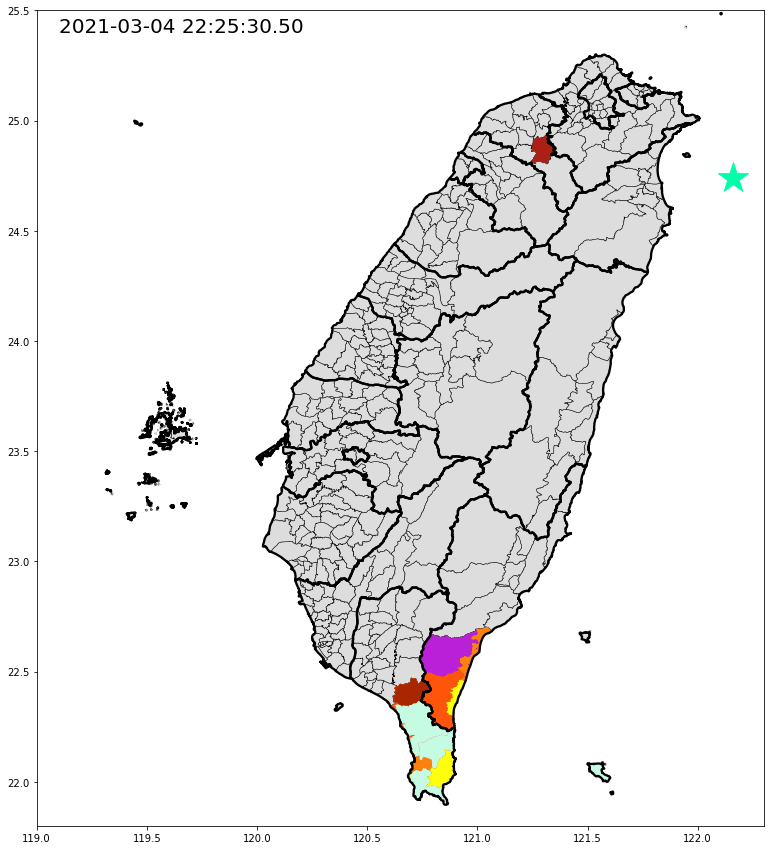

In [38]:
#plotting eq data
color_map = [
        '#C4FBE2',
        '#26FF0B',
        '#FFFE0B',
        '#FF810B',
        '#FF550B',
        '#AC1F14',
        '#A92700',
        '#983476',
        '#BB20D9'
]
cLevel = [1, 2, 3, 4, 5, 5.5, 6, 6.5, 7]
cmap, norm = matplotlib.colors.from_levels_and_colors(cLevel, color_map, extend="max")

#norm = matplotlib.colors.BoundaryNorm(cLevel,9)
#norm = matplotlib.colors.Normalize(vmin=1, vmax=7, clip=True)
#cm = matplotlib.colors.ListedColormap(color_map)
#cmap1 = LinearSegmentedColormap.from_list("my_colormap", color_map, N=9, gamma=1.0)


#eq_data
data = ld.load_data()
frame_rate = 0.1 #
p_radius = 0.095 
s_radius = 0.35

#zero point
origin_x = 119 
origin_y = 21.8 
delta_x = 3.3 
delta_y = 3.7

t_size = 20 #text size

cbw = 2.3 #county_boundary_width
tbw = 0.5 #town_boundary_width
z = 0


#map init
f, axes = plt.subplots(figsize=(15,15))
county.boundary.plot(ax=axes, color="black", edgecolor="black",linewidth=cbw, zorder=2)  #draw counties
l1 = town.plot(ax=axes, color="#dddddd", edgecolor="black", linewidth=tbw, zorder=1)     #draw towns
    
#set pic location
minx, miny, maxx, maxy = (origin_x, origin_y, origin_x + delta_x, origin_y + delta_y)
l1.set_xlim(minx, maxx)
l1.set_ylim(miny, maxy)
current_time = (datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00"))    
axes_time = axes.text(minx+0.1,maxy-0.1,(datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00")), size=t_size)
    
#plotting eq_center
eq_center = pd.DataFrame({"Name":"eq_center", "Latitude":[Lat], "Longitude":[Lon]})
eq_center = gpd.GeoDataFrame(eq_center, geometry=gpd.points_from_xy(eq_center.Longitude, eq_center.Latitude))
eq_center.plot(ax=axes, color="#00ffaa", marker="*", markersize=1000, zorder=3)
op = 0 #temproary

p_radius, s_radius, current_time = gen_gap_frame(axes, current_time, gap_list, frame_rate, axes.texts, p_radius, s_radius)

print("1",current_time)
for item in data: 
    
    date = item["Date"]
    time = item["Time"]
    Areas = item["Areas"]
    AreaDetail = []
    draw_area = gpd.GeoDataFrame()
    data_time = (datetime.strptime(date+" "+time, "%Y-%m-%d %H:%M:%S.%f"))
    
    #if data_time - current_time >= timedelta(seconds=frame_rate):
    while current_time <= data_time:
        current_time += timedelta(seconds=frame_rate)
    print(current_time)
    current_time_str = current_time.strftime("%Y-%m-%d %H_%M_%S.%f")[:-4]
    #plotting key frame
        
    for Area in Areas:
        AreaDetail.append((Area["AreaCode"], Area["Source"], Area["PGA"], float(Area["Intensity"])))

    data = pd.DataFrame(AreaDetail, columns=["AreaCode", "Source", "PGA", "Intensity"])
    data = data.sort_values(by=["AreaCode", "PGA"])
    for i in range(len(data)):
        draw = town[town.TOWNCODE == data.loc[i, "AreaCode"]]
        draw = draw.assign(Intensity = data.loc[i, "Intensity"])
        draw_area = draw_area.append(draw)

    p_circle = plt.Circle((Lon, Lat), radius=p_radius, color="red", lw=2.0, fill=False)
    axes.add_patch(p_circle)
    s_circle = plt.Circle((Lon, Lat), radius=s_radius, color="red", lw=2.0, ls="--", fill=False)
    axes.add_patch(s_circle)
    draw_area.plot("Intensity", ax=axes, cmap=cmap, norm=norm)
    axes.texts[-1].set_text(current_time_str.replace("_",":"))
    axes.figure.savefig(current_time_str+".png")#str(current_time).replace(":", "_")+".png")
    
    p_circle.remove()
    s_circle.remove()
    op += 1

    p_radius, s_radius, current_time = gen_gap_frame(axes, current_time, gap_list, frame_rate, axes.texts, p_radius, s_radius)
    print("2",current_time)

In [40]:
def gen_gap_list(data, cwb_origin_time):
    gap_list = []
    for ind, item in enumerate(data):
        current_datetime = round(datetime.strptime(item["Date"]+" "+item["Time"], "%Y-%m-%d %H:%M:%S.%f").timestamp(), 2)
        next_ind = ind+1
        
        if ind == 0:
            cwb_gap = round(current_datetime - cwb_origin_time, 2)
            gap_list.append(cwb_gap)

        if next_ind == len(data):
            break
        next_datetime = round(datetime.strptime(data[next_ind]["Date"]+" "+data[next_ind]["Time"], "%Y-%m-%d %H:%M:%S.%f").timestamp(), 2)

        gap = round(next_datetime - current_datetime, 2)
        gap_list.append(gap)

    return(gap_list)

gap_list = gen_gap_list(ld.load_data(), cwb_origin_time)
print(gap_list)

[6.7, 6.66, 18.08]


In [41]:
def gen_gap_frame(ax, time, gap_list, frame_rate, texts, p_radius, s_radius):
    #plotting gap frame
    if len(gap_list) > 0:
        gaps = gap_list[0]
        loop_count = math.floor(gaps/frame_rate)

    else:
        return "gap_list len < 0"
    
    for x in range(int(loop_count)):
        time += timedelta(milliseconds=(frame_rate*1000))
        time_str = time.strftime("%Y-%m-%d %H_%M_%S.%f")[:-4]
        p_circle = plt.Circle((Lon, Lat), radius=p_radius, color="red", lw=2.0, fill=False)
        ax.add_patch(p_circle)
        s_circle = plt.Circle((Lon, Lat), radius=s_radius, color="red", lw=2.0, ls="--", fill=False)
        ax.add_patch(s_circle)
        
        p_radius += 0.005
        s_radius += 0.005
        texts[-1].set_text(time_str.replace("_",":"))
        ax.plot()
        ax.figure.savefig(time_str+".png") #(time_str).replace(":", "_")+".png")
        p_circle.remove()
        s_circle.remove()
        print(time)
        
    gap_list.pop(0)
    return p_radius, s_radius, time

In [39]:
import imageio

impath = os.path.join(os.getcwd(), "1")
print(impath)
filenames = os.listdir(impath)
img = []
for filename in filenames:
    print(filename)
    img.append(imageio.imread(os.path.join(impath, filename)))
imageio.mimsave(os.path.join(impath, "test1.gif"), img)

C:\GIT\eqreplay\1
2021-03-04 22_24_59.10.png
2021-03-04 22_24_59.20.png
2021-03-04 22_24_59.30.png
2021-03-04 22_24_59.40.png
2021-03-04 22_24_59.50.png
2021-03-04 22_24_59.60.png
2021-03-04 22_24_59.70.png
2021-03-04 22_24_59.80.png
2021-03-04 22_24_59.90.png
2021-03-04 22_25_00.00.png
2021-03-04 22_25_00.10.png
2021-03-04 22_25_00.20.png
2021-03-04 22_25_00.30.png
2021-03-04 22_25_00.40.png
2021-03-04 22_25_00.50.png
2021-03-04 22_25_00.60.png
2021-03-04 22_25_00.70.png
2021-03-04 22_25_00.80.png
2021-03-04 22_25_00.90.png
2021-03-04 22_25_01.00.png
2021-03-04 22_25_01.10.png
2021-03-04 22_25_01.20.png
2021-03-04 22_25_01.30.png
2021-03-04 22_25_01.40.png
2021-03-04 22_25_01.50.png
2021-03-04 22_25_01.60.png
2021-03-04 22_25_01.70.png
2021-03-04 22_25_01.80.png
2021-03-04 22_25_01.90.png
2021-03-04 22_25_02.00.png
2021-03-04 22_25_02.10.png
2021-03-04 22_25_02.20.png
2021-03-04 22_25_02.30.png
2021-03-04 22_25_02.40.png
2021-03-04 22_25_02.50.png
2021-03-04 22_25_02.60.png
2021-03-04

2021-03-04 22_25_29.70.png
2021-03-04 22_25_29.80.png
2021-03-04 22_25_29.90.png
2021-03-04 22_25_30.00.png
2021-03-04 22_25_30.10.png
2021-03-04 22_25_30.20.png
2021-03-04 22_25_30.30.png
2021-03-04 22_25_30.40.png
2021-03-04 22_25_30.50.png
test1.gif
